<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Histology_Morphometrics_and_Lipids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Environment Setup & Academic Aesthetics
This block loads your required data science and library dependencies while locking in a clean, publication-ready styling layout.

In [1]:
# =========================================================================
# BLOCK 1: ENVIRONMENT SETUP & SCIENTIFIC STYLING
# =========================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configure publication-quality visual environment
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'  # Keeps text editable if exported to vector Illustrator format
sns.set_theme(style="whitegrid")

# Establish cohesive, project-standard color maps for your morphotypes
variant_colors = {'HF': '#66c2a5', 'NF': '#fc8d62'}
morph_order = ['HF', 'NF']

print("✓ Block 1: Analysis libraries loaded and visual styles locked.")

✓ Block 1: Analysis libraries loaded and visual styles locked.


# Block 2: Data Import, Merging, and Tissue Engineering
This block reads both raw CSV sheets, extracts the HF versus NF morph labels directly from your file strings, and builds the missing gastrodermal target proxy (Vacuole_Percentage_Endoderm).

In [4]:
# =========================================================================
# BLOCK 2: DATA LOADING, EXCLUSIONS, AND TISSUE ENGINEERING
# =========================================================================

# 1. Read input CSV files
df_morph = pd.read_csv("Larvae_Morphometrics_Report.csv")
df_cons = pd.read_csv("Larvae_Consumption_Data.csv").dropna(subset=['File_Name'])

# 2. Extract Morph identities uniformly from file name paths
df_morph['Morph'] = df_morph['File_Name'].apply(lambda x: 'HF' if '_HF' in x or '_hf' in x.lower() else ('NF' if '_NF' in x or '_nf' in x.lower() else 'Unknown'))
df_cons['Morph'] = df_cons['File_Name'].apply(lambda x: 'HF' if '_HF' in x or '_hf' in x.lower() else ('NF' if '_NF' in x or '_nf' in x.lower() else 'Unknown'))

# 3. Calculate the missing primary derived proxy: Gastrodermal Energy Packing Density
df_cons['Vacuole_Percentage_Endoderm'] = (df_cons['Total_Vacuole_Area'] / df_cons['Endoderm_Area']) * 100

# 4. Merge data components on File_Name to create an easily managed master workspace
# Assuming df_morph and df_cons are intended to be used directly if no filtering/exclusions are specified yet.
master_df = pd.merge(
    df_morph[['File_Name', 'Morph', 'Ecto_Avg', 'Total_Area_um2', 'Gastro_Cavity_Area_um2']],
    df_cons[['File_Name', 'Morph', 'Vacuole_Percentage_Total', 'Vacuole_Percentage_Endoderm', 'Consumption_Index']],
    on=['File_Name', 'Morph'],
    how='inner'
)

print(f"✓ Block 2 Complete. Master dataframe unified. Samples remaining: {len(master_df)}")
print(master_df['Morph'].value_counts())

✓ Block 2 Complete. Master dataframe unified. Samples remaining: 26
Morph
HF    14
NF    12
Name: count, dtype: int64


# Block 3: Localized Outlier Extraction
To ensure your gold-standard analytical parameters remain perfectly standardized, this standalone function calculates the $1.5 \times \text{IQR}$ barrier independently within each morphotype group before running any stats or plots.

In [5]:
# =========================================================================
# BLOCK 3: GROUP-WISE OUTLIER PRUNING FUNCTION
# =========================================================================

def prune_group_outliers(data, group_col, target_col):
    """
    Slices the dataframe by morph group, isolates fence posts using the
    strict 1.5xIQR standard, and purges anomalies independently.
    """
    clean_dfs = []
    for group_name in data[group_col].unique():
        sub_group = data[data[group_col] == group_name]

        q1 = sub_group[target_col].quantile(0.25)
        q3 = sub_group[target_col].quantile(0.75)
        iqr = q3 - q1

        lower_post = q1 - 1.5 * iqr
        upper_post = q3 + 1.5 * iqr

        # Keep only replicates trapped inside the valid fence rows
        sub_group_clean = sub_group[(sub_group[target_col] >= lower_post) & (sub_group[target_col] <= upper_post)]
        clean_dfs.append(sub_group_clean)

    return pd.concat(clean_dfs)

print("✓ Block 3 Complete: Strict 1.5xIQR group-wise filtering algorithm initialized.")

✓ Block 3 Complete: Strict 1.5xIQR group-wise filtering algorithm initialized.


# Block 4: Automated Testing Engine
This core block performs normality checks (Shapiro-Wilk) group-by-group. If both cohorts are normal, it runs a Welch's t-test. If any group violates normality, it automatically switches to a non-parametric Mann-Whitney U test.


In [7]:
# =========================================================================
# BLOCK 4: AUTOMATED PHYSIOLOGICAL STATISTICAL ASSAY
# =========================================================================

metrics_to_test = ['Ecto_Avg', 'Total_Area_um2', 'Vacuole_Percentage_Total', 'Vacuole_Percentage_Endoderm', 'Consumption_Index']
stat_results_cache = {}

print("=========================================================================")
print("📊 COMPREHENSIVE PATHOLOGICAL TELEMETRY")
print("=========================================================================\n")

for metric in metrics_to_test:
    # Extract data cleaned
    df_metric_clean = prune_group_outliers(master_df, 'Morph', metric)

    hf_sample = df_metric_clean[df_metric_clean['Morph'] == 'HF'][metric]
    nf_sample = df_metric_clean[df_metric_clean['Morph'] == 'NF'][metric]

    # Check Normality assumptions
    _, hf_shapiro_p = stats.shapiro(hf_sample) if len(hf_sample) >= 3 else (0, 0)
    _, nf_shapiro_p = stats.shapiro(nf_sample) if len(nf_sample) >= 3 else (0, 0)

    is_normal = (hf_shapiro_p > 0.05) and (nf_shapiro_p > 0.05)

    # Execute the optimal downstream statistical path dynamically
    if is_normal:
        t_stat, p_value = stats.ttest_ind(hf_sample, nf_sample, equal_var=False)
        test_used = "Welch's Parametric T-Test"
    else:
        t_stat, p_value = stats.mannwhitneyu(hf_sample, nf_sample, alternative='two-sided')
        test_used = "Non-Parametric Mann-Whitney U"

    # Cache the p-value result to overlay directly onto the graphs in Block 5
    stat_results_cache[metric] = p_value

    # Print the clean console report for copying into your methods draft
    print(f"Variable: {metric}")
    print(f"  • Statistical Mechanism: {test_used}")
    print(f"  • Shapiro-Wilk Normality Validation: HF p={hf_shapiro_p:.4f}, NF p={nf_shapiro_p:.4f} (Normal={is_normal})")
    print(f"  • HF Cohort: Mean = {hf_sample.mean():.4f} ± {hf_sample.std():.4f} (n={len(hf_sample)})")
    print(f"  • NF Cohort: Mean = {nf_sample.mean():.4f} ± {nf_sample.std():.4f} (n={len(nf_sample)})")
    print(f"  • Comparative Result Parameter: Test Stat = {t_stat:.4f}, Final Significance p = {p_value:.4f}")
    if p_value < 0.05:
        print("    🚨 SIGNIFICANT REPLICATE TRAJECTORY SEPARATION DIVERGENCE")
    print("-" * 73)

📊 COMPREHENSIVE PATHOLOGICAL TELEMETRY

Variable: Ecto_Avg
  • Statistical Mechanism: Welch's Parametric T-Test
  • Shapiro-Wilk Normality Validation: HF p=0.6785, NF p=0.7296 (Normal=True)
  • HF Cohort: Mean = 43.7071 ± 9.5288 (n=14)
  • NF Cohort: Mean = 51.3489 ± 5.8694 (n=12)
  • Comparative Result Parameter: Test Stat = -2.4983, Final Significance p = 0.0205
    🚨 SIGNIFICANT REPLICATE TRAJECTORY SEPARATION DIVERGENCE
-------------------------------------------------------------------------
Variable: Total_Area_um2
  • Statistical Mechanism: Welch's Parametric T-Test
  • Shapiro-Wilk Normality Validation: HF p=0.8745, NF p=0.9368 (Normal=True)
  • HF Cohort: Mean = 265515.3407 ± 56093.9041 (n=14)
  • NF Cohort: Mean = 305194.0217 ± 75888.9741 (n=12)
  • Comparative Result Parameter: Test Stat = -1.4947, Final Significance p = 0.1506
-------------------------------------------------------------------------
Variable: Vacuole_Percentage_Total
  • Statistical Mechanism: Welch's Param

# Block 5: Global Plot Styling
This defines the aesthetic the plots to ensure consistency.

In [11]:
# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_fig_size = (6, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6 # Used for boxplot and stripplot fill transparency
global_box_width = 0.4
global_asterisk_size = 18
global_asterisk_weight = 'bold'
global_jitter_edgecolor = 'black' # New global setting for jitter outline color
global_jitter_linewidth = 1     # New global setting for jitter outline width
global_y_nbins = 3

print("Styles initialized.")

Styles initialized.


# Block 6: Individual 600 DPI Publication Graph Generator
This final block iterates through your metrics, extracts clean outliers, overlays raw individual data points to guarantee tracking transparency, applies your color map palette, prints the precise statistical p-value outcome on the frame, and saves individual, high-resolution vector files at 600 DPI.

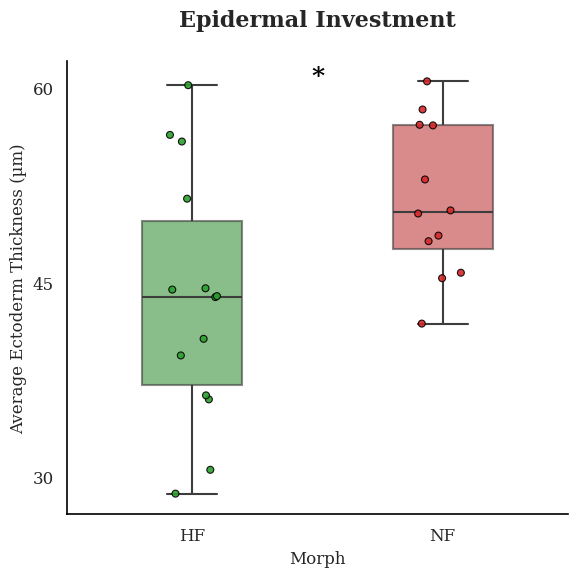

Statistical Outcome for Ecto_Avg: p = 0.0205 *
✓ Standalone image exported successfully: larvae_final_cleaned_Ecto_Avg_plot.png [600 DPI Print-Ready]



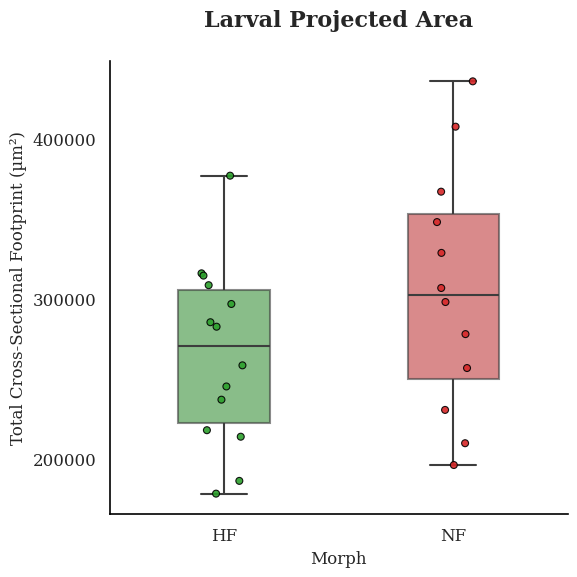

Statistical Outcome for Total_Area_um2: p = 0.1506 (NS)
✓ Standalone image exported successfully: larvae_final_cleaned_Total_Area_um2_plot.png [600 DPI Print-Ready]



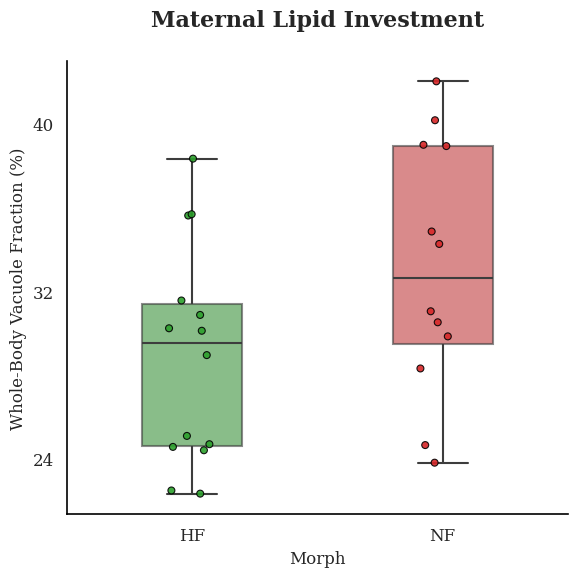

Statistical Outcome for Vacuole_Percentage_Total: p = 0.0738 (NS)
✓ Standalone image exported successfully: larvae_final_cleaned_Vacuole_Percentage_Total_plot.png [600 DPI Print-Ready]



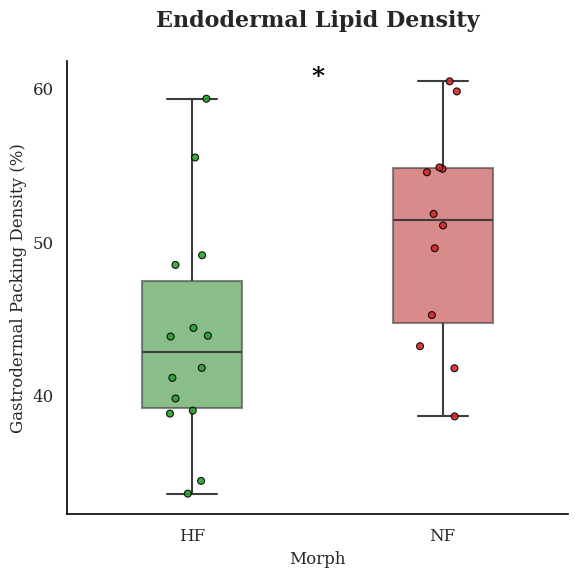

Statistical Outcome for Vacuole_Percentage_Endoderm: p = 0.0260 *
✓ Standalone image exported successfully: larvae_final_cleaned_Vacuole_Percentage_Endoderm_plot.png [600 DPI Print-Ready]



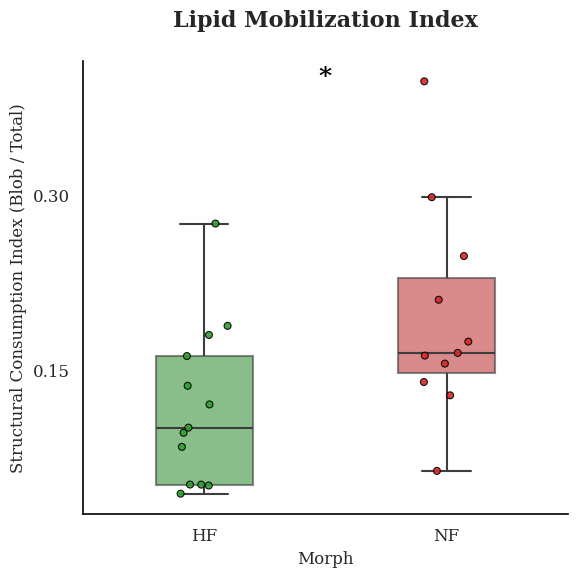

Statistical Outcome for Consumption_Index: p = 0.0352 *
✓ Standalone image exported successfully: larvae_final_cleaned_Consumption_Index_plot.png [600 DPI Print-Ready]



In [25]:
# =========================================================================
# BLOCK 6: HIGH-RESOLUTION INDIVIDUAL PLOT LOOP (600 DPI)
# =========================================================================

# Clear out descriptive labels for your layout y-axes
y_label_dictionary = {
    'Ecto_Avg': 'Average Ectoderm Thickness (µm)',
    'Total_Area_um2': 'Total Cross-Sectional Footprint (µm²)',
    'Vacuole_Percentage_Total': 'Whole-Body Vacuole Fraction (%)',
    'Vacuole_Percentage_Endoderm': 'Gastrodermal Packing Density (%)',
    'Consumption_Index': 'Structural Consumption Index (Blob / Total)'
}

title_dictionary = {
    'Ecto_Avg': 'Epidermal Investment',
    'Total_Area_um2': 'Larval Projected Area',
    'Vacuole_Percentage_Total': 'Maternal Lipid Investment',
    'Vacuole_Percentage_Endoderm': 'Endodermal Lipid Density',
    'Consumption_Index': 'Lipid Mobilization Index'
}

for metric in metrics_to_test:
    # Extract specific metric dataset cleaned using your lab method standard
    df_plot_clean = prune_group_outliers(master_df, 'Morph', metric)

    # Initialize standalone figure canvas using global size
    fig, ax = plt.subplots(figsize=global_fig_size)

    # Remove Chartjunk: Disable grid and remove top/right spines
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Draw standard underlying median box distribution layout using global box parameters
    sns.boxplot(
        ax=ax,
        data=df_plot_clean,
        x='Morph',
        y=metric,
        hue='Morph',
        order=morph_order,
        palette=variant_colors,
        width=global_box_width,
        fliersize=0,      # Outliers already removed via IQR loop
        linewidth=1.5,
        boxprops=dict(alpha=global_alpha),
        legend=False
    )

    # Overlay raw data points: color matched to morph, with slim black outlines
    sns.stripplot(
        ax=ax,
        data=df_plot_clean,
        x='Morph',
        y=metric,
        hue='Morph',
        order=morph_order,
        palette=variant_colors,
        size=global_marker_size,
        alpha=0.9,
        jitter=global_jitter,
        edgecolor=global_jitter_edgecolor,
        linewidth=0.8,     # Slim outline
        legend=False
    )

    # Formatting text details
    ax.set_title(title_dictionary[metric], pad=plt.rcParams['axes.titlepad'])
    ax.set_ylabel(y_label_dictionary[metric])
    ax.set_xlabel('Morph')

    # Ensure y-axis has clean breaks based on global nbins preference
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=global_y_nbins))

    # Extract the custom p-value compiled in Block 4 for the printed summary and star logic
    current_p = stat_results_cache[metric]
    if current_p < 0.001:
        stars = "***"
    elif current_p < 0.01:
        stars = "**"
    elif current_p < 0.05:
        stars = "*"
    else:
        stars = "(NS)"

    significance_string = f"p = {current_p:.4f} {stars}"

    # Overlay only the black asterisks on the plot if result is significant (p < 0.05)
    if stars != "(NS)":
        ymin, ymax = ax.get_ylim()
        text_y_position = ymax - (ymax - ymin) * 0.05
        ax.text(0.5, text_y_position, stars, horizontalalignment='center',
                fontsize=global_asterisk_size, color='black', weight=global_asterisk_weight)

    plt.tight_layout()

    # SHOW THE PLOT IN COLAB
    plt.show()

    # PRINT STATS SUMMARY AFTER FIGURE
    print(f"Statistical Outcome for {metric}: {significance_string}")

    # Export individual high-impact high-resolution asset prints
    file_export_name = f"larvae_final_cleaned_{metric}_plot.png"
    fig.savefig(file_export_name, dpi=600, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Standalone image exported successfully: {file_export_name} [600 DPI Print-Ready]\n")